In [38]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

nav['date'] = pd.to_datetime(nav['date'])

print(nav.head())

   amfi_code       date       nav
0     100016 2022-01-03  520.4608
1     100016 2022-01-04  515.0971
2     100016 2022-01-05  521.7239
3     100016 2022-01-06  515.7880
4     100016 2022-01-07  515.1639


In [39]:
print("Total Schemes:", nav['amfi_code'].nunique())
print("Total Records:", len(nav))

Total Schemes: 40
Total Records: 46000


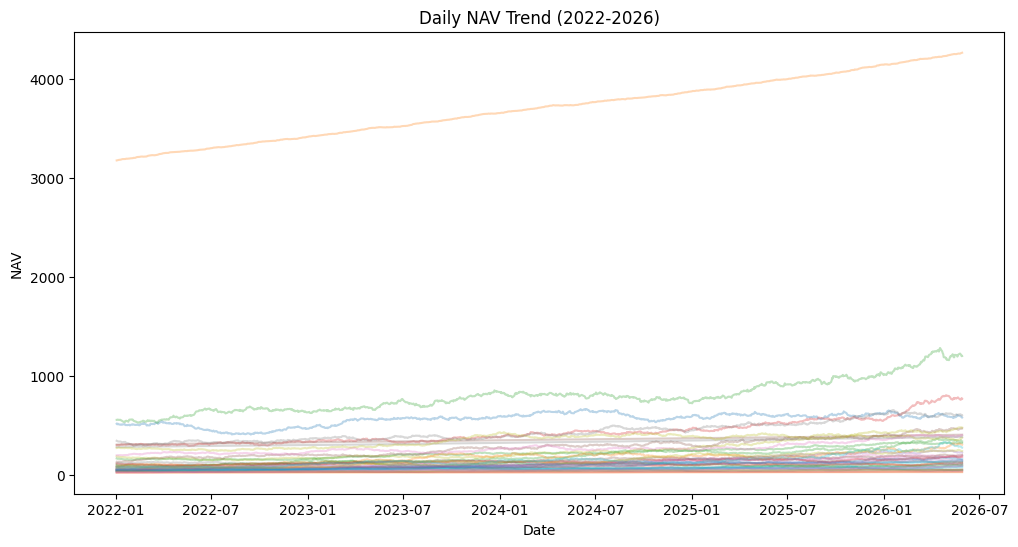

In [40]:
plt.figure(figsize=(12,6))

for code in nav['amfi_code'].unique():
    subset = nav[nav['amfi_code'] == code]

    plt.plot(
        subset['date'],
        subset['nav'],
        alpha=0.3
    )

plt.title("Daily NAV Trend (2022-2026)")
plt.xlabel("Date")
plt.ylabel("NAV")

plt.show()

 NAV Trend Analysis - Findings

1. The dataset contains NAV history for 40 mutual fund schemes.

2. Most schemes show an overall upward trend between 2022 and 2026.

3. A few schemes demonstrate significantly higher NAV values compared to others.

4. Several schemes exhibit moderate fluctuations, indicating varying levels of volatility.

5. The overall mutual fund market trend appears positive over the observed period.

6. The dataset contains 46,000 NAV records covering multiple years of performance history.


In [37]:
import pandas as pd

aum_df = pd.read_csv("../data/processed/cleaned_aum_by_fund_house.csv")

print(aum_df.head())

print("\nColumns:")
print(aum_df.columns)

print("\nShape:")
print(aum_df.shape)

         date           fund_house  aum_lakh_crore  aum_crore  num_schemes
0  2022-03-31      SBI Mutual Fund            6.05     605000          186
1  2022-03-31  ICICI Prudential MF            4.65     465000          216
2  2022-03-31     HDFC Mutual Fund            4.35     435000          195
3  2022-03-31      Nippon India MF            2.70     270000          177
4  2022-03-31    Kotak Mahindra MF            2.70     270000          168

Columns:
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='object')

Shape:
(90, 5)


In [41]:
aum_df['date'] = pd.to_datetime(aum_df['date'])

aum_df['year'] = aum_df['date'].dt.year

print(aum_df.head())

        date           fund_house  aum_lakh_crore  aum_crore  num_schemes  \
0 2022-03-31      SBI Mutual Fund            6.05     605000          186   
1 2022-03-31  ICICI Prudential MF            4.65     465000          216   
2 2022-03-31     HDFC Mutual Fund            4.35     435000          195   
3 2022-03-31      Nippon India MF            2.70     270000          177   
4 2022-03-31    Kotak Mahindra MF            2.70     270000          168   

   year  
0  2022  
1  2022  
2  2022  
3  2022  
4  2022  


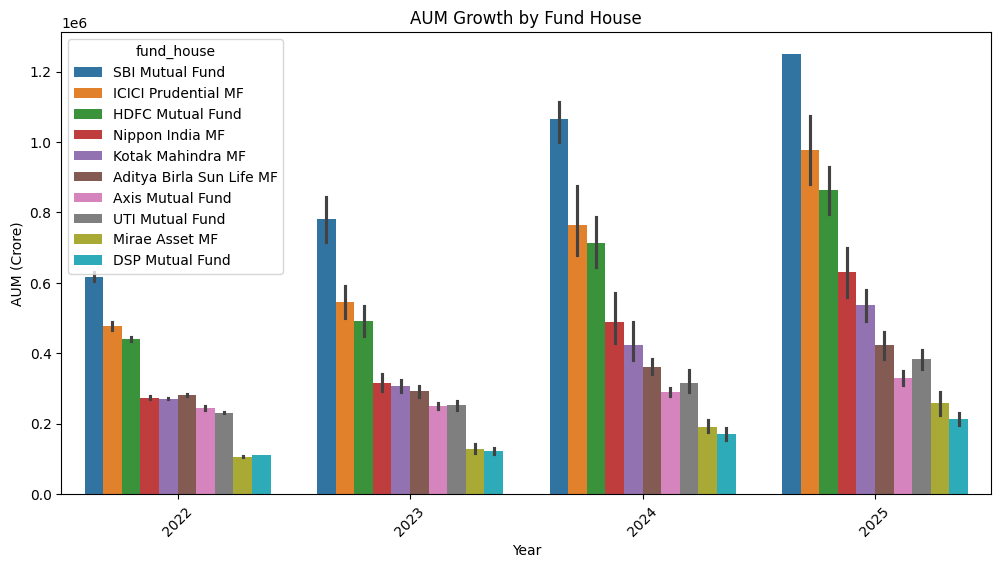

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    data=aum_df,
    x='year',
    y='aum_crore',
    hue='fund_house'
)

plt.title("AUM Growth by Fund House")
plt.xlabel("Year")
plt.ylabel("AUM (Crore)")
plt.xticks(rotation=45)

plt.show()

   AUM Growth Analysis - Findings

1. SBI Mutual Fund maintained the highest Assets Under Management (AUM) throughout the observed period.

2. ICICI Prudential MF and HDFC Mutual Fund consistently ranked among the top fund houses by AUM.

3. Most fund houses showed year-over-year growth from 2022 to 2025.

4. The overall increase in AUM indicates growing investor participation in mutual funds.

5. Large fund houses experienced stronger asset growth compared to smaller fund houses.


In [43]:
transactions = pd.read_csv(
    "../data/processed/investor_transactions_cleaned.csv"
)

print(transactions.head())

print("\nColumns:")
print(transactions.columns)

  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       REDEMPTION      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          LUMPSUM        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   VERIFIED  
1       Cheque   VERIFIED  
2      M

In [46]:
transactions['transaction_date'] = pd.to_datetime(
    transactions['transaction_date']
)

transactions['month'] = (
    transactions['transaction_date']
    .dt.to_period('M')
)

print(transactions[['transaction_date','month']].head())

  transaction_date    month
0       2024-01-01  2024-01
1       2024-01-01  2024-01
2       2024-01-01  2024-01
3       2024-01-01  2024-01
4       2024-01-01  2024-01


In [47]:
sip_transactions = transactions[
    transactions['transaction_type'] == 'SIP'
]

sip_monthly = (
    sip_transactions
    .groupby('month')['amount_inr']
    .sum()
    .reset_index()
)

print(sip_monthly.head())

     month  amount_inr
0  2024-01    12635349
1  2024-02    12613376
2  2024-03    12088413
3  2024-04    13512385
4  2024-05    13218606


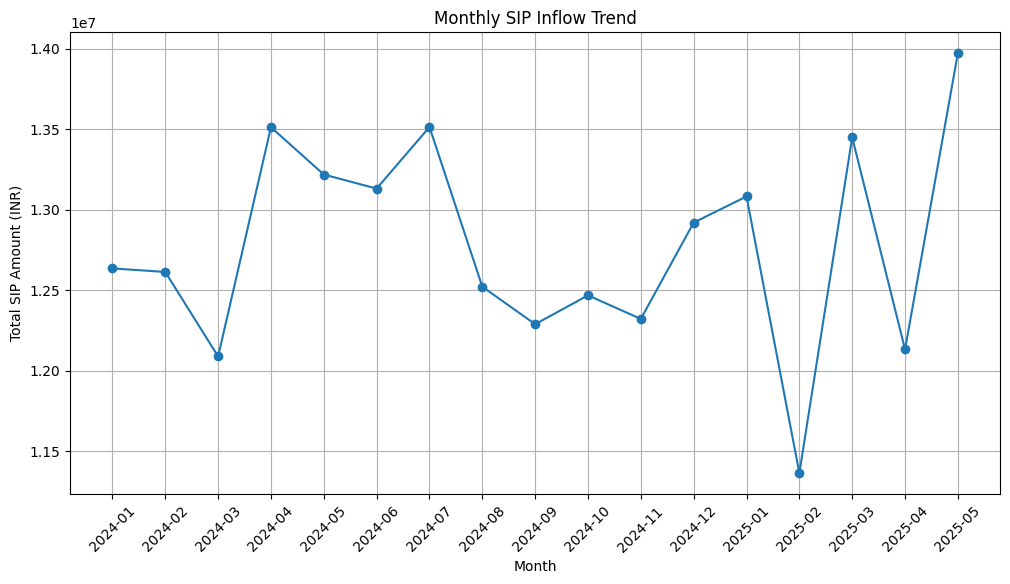

In [49]:
import matplotlib.pyplot as plt

sip_monthly['month'] = sip_monthly['month'].astype(str)

plt.figure(figsize=(12,6))

plt.plot(
    sip_monthly['month'],
    sip_monthly['amount_inr'],
    marker='o'
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("Total SIP Amount (INR)")
plt.xticks(rotation=45)

plt.grid(True)

plt.show()

   SIP Inflow Trend - Findings

1. Monthly SIP inflows remained consistently strong throughout the analysis period.

2. SIP contributions showed moderate month-to-month fluctuations.

3. A temporary decline was observed during February 2025.

4. SIP inflows recovered strongly in the following months, indicating sustained investor confidence.

5. The highest SIP inflow was recorded toward the end of the observed period.

6. Overall trends suggest continued growth in systematic mutual fund investments.


In [51]:
pivot_table = category_df.pivot_table(
    values='net_inflow_crore',
    index='category',
    columns='month'
)

print(pivot_table.head())

month            2024-04  2024-05  2024-06  2024-07  2024-08  2024-09  \
category                                                                
ELSS               466.0    553.0    472.0    471.0    499.0    537.0   
Flexi Cap         4947.0   5529.0   4478.0   4869.0   5562.0   5397.0   
Gilt               784.0    836.0    864.0    959.0    952.0    925.0   
Hybrid            2955.0   3487.0   3163.0   3291.0   3684.0   3015.0   
Large & Mid Cap   4214.0   4368.0   4610.0   5023.0   5411.0   4528.0   

month            2024-10  2024-11  2024-12  2025-01  2025-02  2025-03  
category                                                               
ELSS               537.0    571.0    521.0    516.0    437.0    500.0  
Flexi Cap         6004.0   6111.0   4654.0   5603.0   6068.0   4767.0  
Gilt               898.0    704.0    831.0    744.0    942.0    956.0  
Hybrid            3314.0   3264.0   3538.0   2967.0   3360.0   2830.0  
Large & Mid Cap   4581.0   5556.0   4878.0   4816.0   55

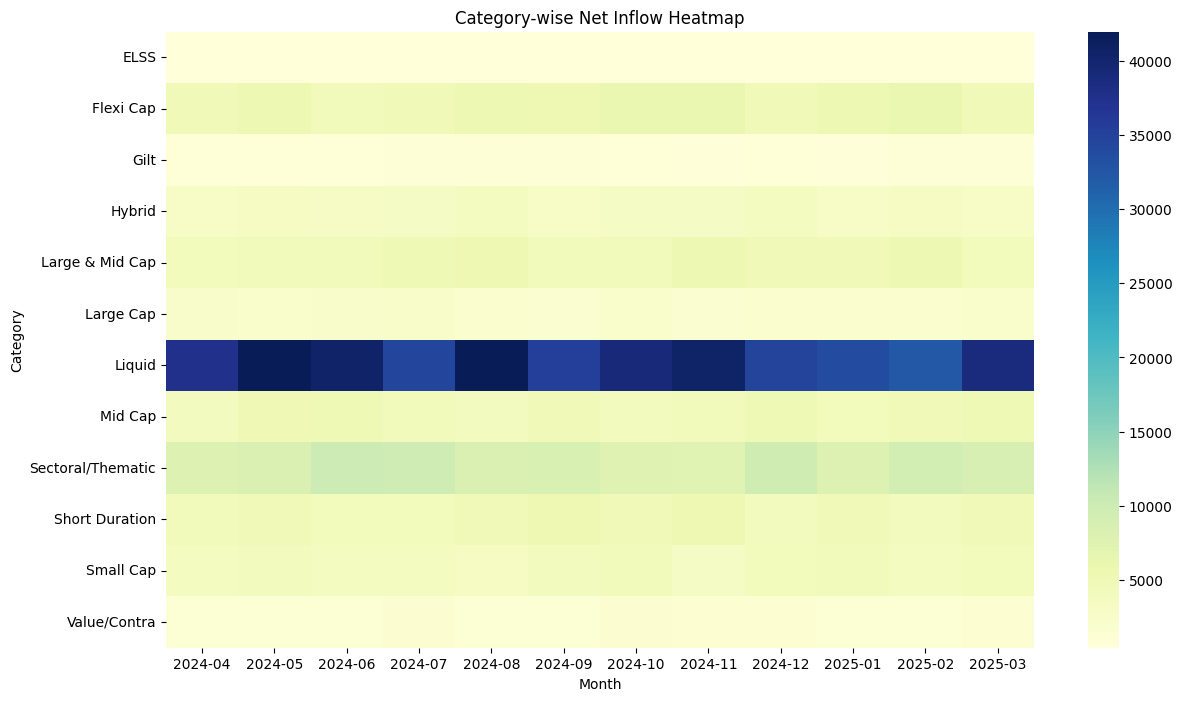

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14,8))

sns.heatmap(
    pivot_table,
    annot=False,
    cmap='YlGnBu'
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

   Category Heatmap Analysis - Findings

1. Liquid Funds consistently recorded the highest net inflows across the observed period.

2. Sectoral/Thematic Funds showed strong investor interest and maintained relatively high inflows.

3. Flexi Cap, Mid Cap, Small Cap, and Large & Mid Cap categories attracted steady investments throughout the year.

4. ELSS, Gilt, and Value/Contra categories experienced comparatively lower inflows.

5. Most categories displayed stable investment patterns without extreme fluctuations.

6. The heatmap highlights investor preference for liquidity-oriented and growth-oriented mutual fund categories.


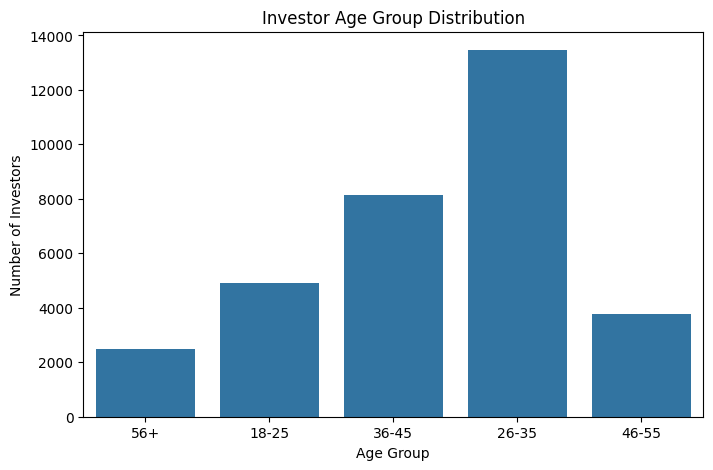

In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(
    data=investor_df,
    x='age_group'
)

plt.title("Investor Age Group Distribution")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.show()

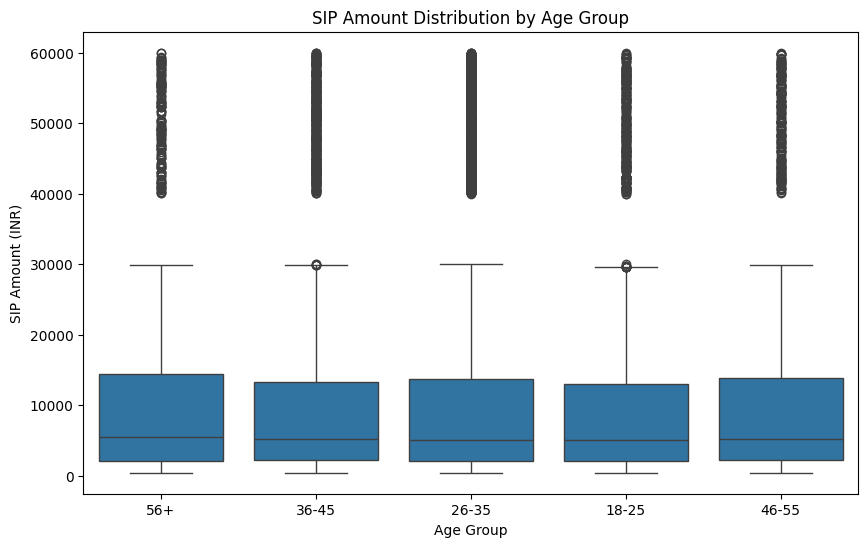

In [56]:
sip_df = investor_df[
    investor_df['transaction_type'] == 'SIP'
]

plt.figure(figsize=(10,6))

sns.boxplot(
    data=sip_df,
    x='age_group',
    y='amount_inr'
)

plt.title("SIP Amount Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("SIP Amount (INR)")

plt.show()

   SIP Amount Distribution by Age Group - Findings

1. Median SIP investment amounts are relatively similar across all age groups.

2. The distribution of SIP contributions shows substantial variation within each age segment.

3. High-value SIP investments are present across all age groups.

4. Numerous outliers indicate the presence of investors making significantly larger SIP contributions.

5. While the 26-35 age group contains the largest number of investors, investment amounts are not dramatically different from other age groups.

6. SIP participation appears broadly distributed across investor demographics.


In [57]:
state_sip = (
    transactions
    .groupby('state')['amount_inr']
    .sum()
    .reset_index()
)

state_sip = state_sip.sort_values(
    by='amount_inr',
    ascending=False
)

print(state_sip.head())

            state  amount_inr
6          Punjab   315780459
8      Tamil Nadu   315177237
4  Madhya Pradesh   308312493
7       Rajasthan   298645822
1         Gujarat   298358940


In [58]:
import plotly.express as px

fig = px.bar(
    state_sip,
    x='amount_inr',
    y='state',
    orientation='h',
    title='State-wise SIP Distribution'
)

fig.show()

   Geographic Distribution Analysis - Findings

1. Mutual fund investments are distributed across multiple Indian states.

2. Punjab recorded the highest total investment amount in the dataset.

3. Tamil Nadu and Madhya Pradesh also contributed significantly to total investments.

4. Investment participation is relatively balanced across major states, with no extreme concentration.

5. Geographic distribution indicates widespread investor engagement across different regions.

6. State-level analysis helps identify key markets for mutual fund growth and investor outreach.


In [59]:
folio_df = pd.read_csv(
    "../data/processed/cleaned_industry_folio_count.csv"
)

print(folio_df.head())

print("\nColumns:")
print(folio_df.columns)

print("\nShape:")
print(folio_df.shape)

     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  

Columns:
Index(['month', 'total_folios_crore', 'equity_folios_crore',
       'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore'],
      dtype='object')

Shape:
(21, 6)


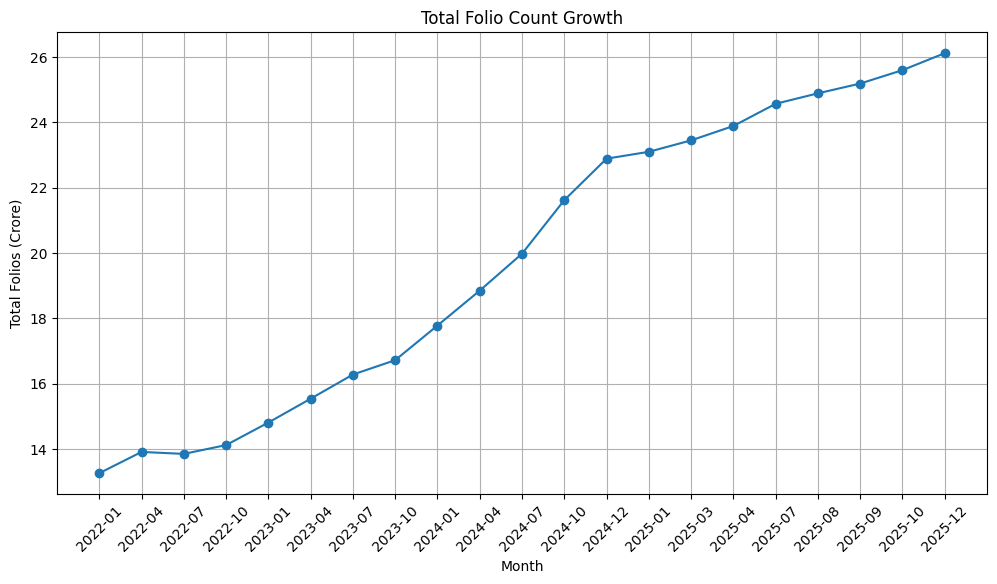

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    folio_df['month'],
    folio_df['total_folios_crore'],
    marker='o'
)

plt.title("Total Folio Count Growth")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

In [62]:
start_folio = folio_df['total_folios_crore'].iloc[0]
end_folio = folio_df['total_folios_crore'].iloc[-1]

growth_pct = (
    (end_folio - start_folio)
    / start_folio
) * 100

print("Starting Folios:", start_folio, "Crore")
print("Ending Folios:", end_folio, "Crore")
print("Growth Percentage:", round(growth_pct, 2), "%")

Starting Folios: 13.26 Crore
Ending Folios: 26.12 Crore
Growth Percentage: 96.98 %


In [63]:
years = 4

cagr = (
    (end_folio / start_folio) ** (1 / years) - 1
) * 100

print("CAGR:", round(cagr, 2), "%")

CAGR: 18.47 %


   Folio Count Growth Analysis - Findings

1. Total mutual fund folios increased from 13.26 crore in 2022 to 26.12 crore in 2025.

2. The folio base nearly doubled during the analysis period, indicating strong investor participation.

3. The overall growth percentage was approximately 96.98%.

4. The Compound Annual Growth Rate (CAGR) was 18.47%, reflecting sustained industry expansion.

5. The trend remained consistently upward without significant declines.

6. Increasing folio counts suggest growing awareness and adoption of mutual fund investments among retail investors.


In [66]:
corr_df = scheme_df[
    [
        'return_1yr_pct',
        'return_3yr_pct',
        'return_5yr_pct',
        'alpha',
        'beta',
        'sharpe_ratio',
        'sortino_ratio',
        'std_dev_ann_pct',
        'max_drawdown_pct',
        'aum_crore',
        'expense_ratio_pct',
        'morningstar_rating'
    ]
]

In [67]:
corr = corr_df.corr()

print(corr)

                    return_1yr_pct  return_3yr_pct  return_5yr_pct     alpha  \
return_1yr_pct            1.000000        0.910491        0.879870 -0.195518   
return_3yr_pct            0.910491        1.000000        0.929076 -0.231775   
return_5yr_pct            0.879870        0.929076        1.000000 -0.228376   
alpha                    -0.195518       -0.231775       -0.228376  1.000000   
beta                      0.692502        0.732442        0.699485 -0.237821   
sharpe_ratio             -0.508997       -0.519123       -0.483935  0.235492   
sortino_ratio            -0.521809       -0.531099       -0.481465  0.220688   
std_dev_ann_pct           0.907561        0.956132        0.940751 -0.300885   
max_drawdown_pct         -0.457619       -0.479871       -0.507809  0.160525   
aum_crore                 0.096182        0.062200        0.143765  0.310481   
expense_ratio_pct         0.458151        0.514664        0.456199 -0.233115   
morningstar_rating        0.082746      

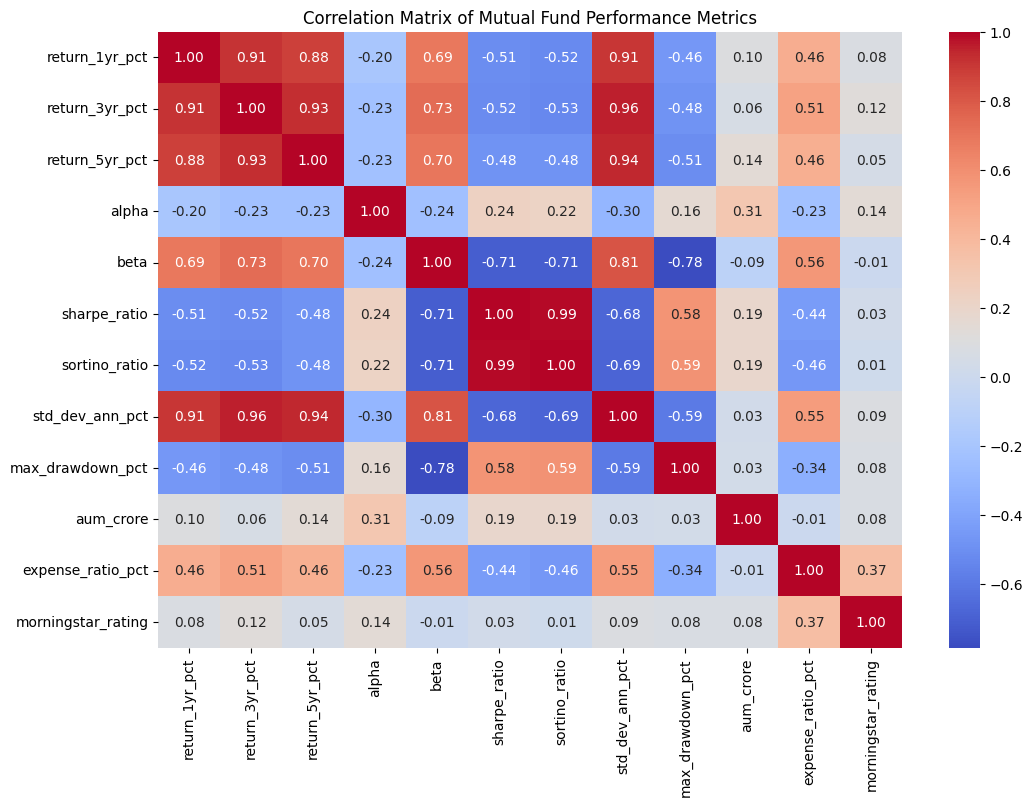

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix of Mutual Fund Performance Metrics")

plt.show()

   Correlation Matrix Analysis - Findings

1. Return metrics across different investment horizons show strong positive correlations, indicating consistency in fund performance.

2. Sharpe Ratio and Sortino Ratio exhibit an almost perfect positive correlation (0.99), reflecting their similar approach to risk-adjusted return measurement.

3. Higher returns are associated with higher volatility, as shown by the strong positive relationship between return metrics and standard deviation.

4. Beta demonstrates a strong negative relationship with risk-adjusted performance measures such as Sharpe Ratio and Sortino Ratio.

5. Assets Under Management (AUM) show weak correlations with return metrics, suggesting fund size alone does not determine performance.

6. Correlation analysis highlights important relationships between return, risk, and fund characteristics that can support investment decision-making.


In [70]:
sector_summary = (
    holdings_df
    .groupby('sector')['weight_pct']
    .sum()
    .reset_index()
)

sector_summary = sector_summary.sort_values(
    by='weight_pct',
    ascending=False
)

print(sector_summary.head(10))

            sector  weight_pct
1          Banking      652.26
7               IT      455.47
11          Pharma      407.45
0       Automobile      323.65
13       Utilities      265.54
6             FMCG      229.11
8   Infrastructure      192.16
4      Diversified      169.23
12         Telecom      145.62
3   Consumer Goods      127.61


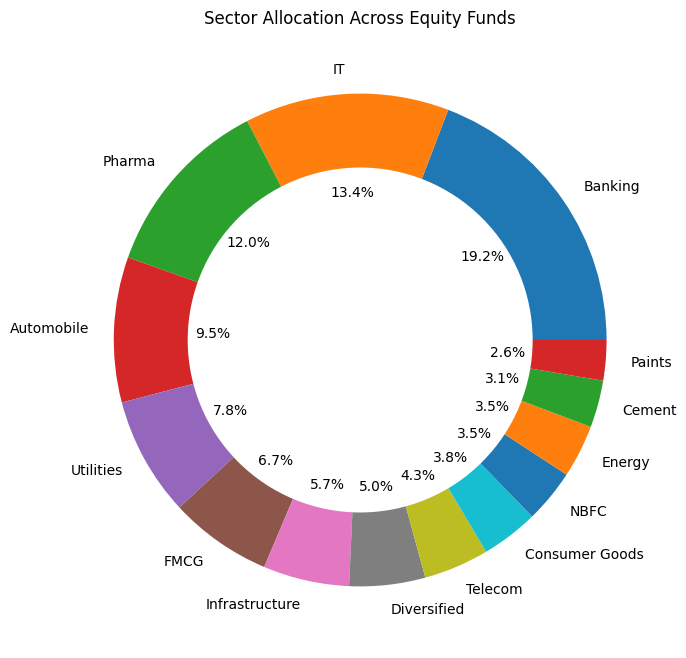

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))

plt.pie(
    sector_summary['weight_pct'],
    labels=sector_summary['sector'],
    autopct='%1.1f%%'
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc='white'
)

fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

   Sector Allocation Analysis - Findings

1. Banking is the largest sector allocation, accounting for approximately 19.2% of total portfolio exposure.

2. IT and Pharma sectors represent significant portions of equity fund holdings, indicating strong allocation toward growth-oriented industries.

3. Automobile and Utilities sectors also contribute meaningful portfolio weight.

4. Portfolio holdings are diversified across multiple sectors, reducing concentration risk.

5. Defensive sectors such as FMCG and Pharma maintain substantial representation within portfolios.

6. Sector allocation analysis reveals fund managers' preference toward financial services, technology, healthcare, and consumer-focused industries.
